In [37]:
import pandas as pd

In [38]:
df = pd.read_csv("Senftenberg IV Energy Meter Janitza UMG 104 2024.csv" , sep=';' , thousands=',', index_col=0, parse_dates=True, dayfirst=True)

In [39]:
df = df.drop('Unnamed: 2', axis=1)
df = df.rename(columns={'Senftenberg IV Janitza UMG 104 AC Power L1234 [W] [avg]': 'PV'})
df.index = df.index - pd.Timedelta(minutes=15)
df.head()


,PV
Date,
2024-01-01 00:00:00,NaN
2024-01-01 00:15:00,NaN
2024-01-01 00:30:00,NaN
2024-01-01 00:45:00,126471.00
2024-01-01 01:00:00,124282.47


<Axes: xlabel='Date'>

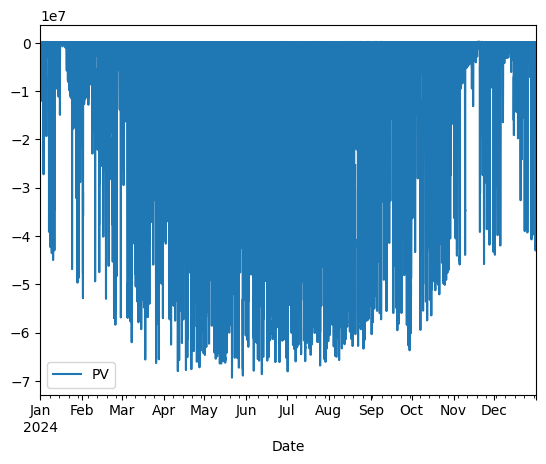

In [40]:
df.plot()

In [41]:
df['PV'] = df.PV * -1 / 10**6  # W to MW and invert sign

In [46]:
df.fillna(-0.125, inplace=True)
df.loc[df['PV'] < 0, 'PV'] = 0
df.head()

,PV
Date,
2024-01-01 00:00:00,0.0
2024-01-01 00:15:00,0.0
2024-01-01 00:30:00,0.0
2024-01-01 00:45:00,0.0
2024-01-01 01:00:00,0.0


In [47]:
df.to_csv("2024_pv.csv")